# Example prediction on a single test image

This notebook gives example code to make a single disparity prediction for one test image.

The file `test_simple.py` shows a more complete version of this code, which additionally:
- Can run on GPU or CPU (this notebook only runs on CPU)
- Can predict for a whole folder of images, not just a single image
- Saves predictions to `.npy` files and disparity images.

In [28]:
from __future__ import absolute_import, division, print_function
%matplotlib inline

import os
import numpy as np
import PIL.Image as pil
import matplotlib.pyplot as plt

import torch
from torchvision import transforms

import networks
from utils import download_model_if_doesnt_exist

## Setting up network and loading weights

In [29]:
# Load all 3 models: 2 MonoDepth2 + 1 ManyDepth
monodepth_model_names = ["mono_default_weights_19", "weights_19_monoHR"]
manydepth_model_names = ["KITTI_MR"]

models = []

# --- Load MonoDepth2 Models ---
for model_name in monodepth_model_names:
    download_model_if_doesnt_exist(model_name)
    model_path = os.path.join("models", model_name)
    
    encoder_path = os.path.join(model_path, "encoder.pth")
    depth_decoder_path = os.path.join(model_path, "depth.pth")

    loaded_dict_enc = torch.load(encoder_path, map_location='cpu', weights_only=False)

    print(f"Loading {model_name} (MonoDepth2 mode)...")
    
    # Initialize Encoder
    encoder = networks.ResnetEncoder(18, False)
    
    # Initialize Decoder (Handle HR variant)
    if model_name == "weights_19_monoHR":
        depth_decoder = networks.HRDepthDecoder(num_ch_enc=encoder.num_ch_enc, scales=range(4))
    else:
        depth_decoder = networks.DepthDecoder(num_ch_enc=encoder.num_ch_enc, scales=range(4))
    
    # Load State Dicts
    filtered_dict_enc = {k: v for k, v in loaded_dict_enc.items() if k in encoder.state_dict()}
    encoder.load_state_dict(filtered_dict_enc)
    
    loaded_dict_dec = torch.load(depth_decoder_path, map_location='cpu')
    depth_decoder.load_state_dict(loaded_dict_dec)
    
    encoder.eval()
    depth_decoder.eval()
    
    models.append({
        'name': model_name,
        'encoder': encoder,
        'decoder': depth_decoder,
        'pose_encoder': None,
        'pose_decoder': None,
        'feed_height': loaded_dict_enc['height'],
        'feed_width': loaded_dict_enc['width']
    })

# --- Load ManyDepth Models ---
for model_name in manydepth_model_names:
    download_model_if_doesnt_exist(model_name)
    model_path = os.path.join("models", model_name)
    
    encoder_path = os.path.join(model_path, "encoder.pth")
    depth_decoder_path = os.path.join(model_path, "depth.pth")

    loaded_dict_enc = torch.load(encoder_path, map_location='cpu', weights_only=False)

    print(f"Loading {model_name} (ManyDepth mode)...")
    
    # Initialize Matching Encoder
    encoder = networks.ResnetEncoderMatching(
        num_layers=18,
        pretrained=False,
        input_width=loaded_dict_enc['width'],
        input_height=loaded_dict_enc['height'],
        adaptive_bins=True,
        min_depth_bin=loaded_dict_enc['min_depth_bin'],
        max_depth_bin=loaded_dict_enc['max_depth_bin'],
        depth_binning='linear',
        num_depth_bins=96
    )
    
    # Initialize Depth Decoder
    depth_decoder = networks.DepthDecoder(num_ch_enc=encoder.num_ch_enc, scales=range(4))
    
    # Initialize Pose Networks
    pose_enc_path = os.path.join(model_path, "pose_encoder.pth")
    pose_dec_path = os.path.join(model_path, "pose.pth")
    
    pose_encoder = networks.ResnetEncoder(18, False, num_input_images=2)
    pose_decoder = networks.PoseDecoder(pose_encoder.num_ch_enc, num_input_features=1, num_frames_to_predict_for=2)
    
    # Load State Dicts
    filtered_dict_enc = {k: v for k, v in loaded_dict_enc.items() if k in encoder.state_dict()}
    encoder.load_state_dict(filtered_dict_enc)
    
    depth_decoder.load_state_dict(torch.load(depth_decoder_path, map_location='cpu'))
    pose_encoder.load_state_dict(torch.load(pose_enc_path, map_location='cpu'))
    pose_decoder.load_state_dict(torch.load(pose_dec_path, map_location='cpu'))
    
    # Set all to eval
    encoder.eval()
    depth_decoder.eval()
    pose_encoder.eval()
    pose_decoder.eval()
    
    models.append({
        'name': model_name,
        'encoder': encoder,
        'decoder': depth_decoder,
        'pose_encoder': pose_encoder,
        'pose_decoder': pose_decoder,
        'feed_height': loaded_dict_enc['height'],
        'feed_width': loaded_dict_enc['width'],
        'min_depth_bin': loaded_dict_enc.get('min_depth_bin'),
        'max_depth_bin': loaded_dict_enc.get('max_depth_bin')
    })

print(f"\n✓ Successfully loaded {len(models)} models:")
for model in models:
    print(f"  - {model['name']}")


Loading mono_default_weights_19 (MonoDepth2 mode)...
Loading weights_19_monoHR (MonoDepth2 mode)...
Loading weights_19_monoHR (MonoDepth2 mode)...
Loading KITTI_MR (ManyDepth mode)...
Loading KITTI_MR (ManyDepth mode)...

✓ Successfully loaded 3 models:
  - mono_default_weights_19
  - weights_19_monoHR
  - KITTI_MR

✓ Successfully loaded 3 models:
  - mono_default_weights_19
  - weights_19_monoHR
  - KITTI_MR


## Loading the test image and preprocessing

In [30]:
image_path = "assets/test_image.jpg"

input_image = pil.open(image_path).convert('RGB')
original_width, original_height = input_image.size

# Prepare input images for all models (they may have different input sizes)
input_images = []
for model in models:
    feed_height = model['feed_height']
    feed_width = model['feed_width']
    input_image_resized = input_image.resize((feed_width, feed_height), pil.LANCZOS)
    input_image_pytorch = transforms.ToTensor()(input_image_resized).unsqueeze(0)
    input_images.append(input_image_pytorch)

## Prediction using the PyTorch model

In [31]:
from layers import transformation_from_parameters

# Generate predictions for all models
predictions = []

with torch.no_grad():
    for i, (model, input_img) in enumerate(zip(models, input_images)):
        
        # Get dimensions
        batch_size, _, height, width = input_img.shape
        
        # Check if this is a ManyDepth model
        if model.get('pose_encoder') is not None:
            
            # ManyDepth requires source images and camera intrinsics
            # Since we're doing single image inference, we use dummy zero tensors
            # which signals the encoder to skip the cost volume computation
            
            # Create dummy lookup images (shape: Batch, Num_Frames, Channels, Height, Width)
            lookup_images = torch.zeros(batch_size, 1, 3, height, width).to(input_img.device)
            
            # Create dummy camera intrinsics (shape: Batch, 3, 3)
            K = torch.eye(3).float().unsqueeze(0).repeat(batch_size, 1, 1).to(input_img.device)
            K[:, 0, 0] = width      # fx
            K[:, 1, 1] = width      # fy
            K[:, 0, 2] = width / 2  # cx
            K[:, 1, 2] = height / 2 # cy
            invK = torch.inverse(K)
            
            # Create dummy pose (zero pose signals encoder to skip cost volume)
            poses = torch.zeros(batch_size, 1, 4, 4).to(input_img.device)
            
            # Forward pass through matching encoder
            features, _, _ = model['encoder'](
                current_image=input_img,
                lookup_images=lookup_images,
                poses=poses,
                K=K,
                invK=invK,
                min_depth_bin=model['min_depth_bin'],
                max_depth_bin=model['max_depth_bin']
            )
            
        else:
            # Standard MonoDepth2 model - just pass the single image
            features = model['encoder'](input_img)

        # Decode features to get disparity
        outputs = model['decoder'](features)
        disp = outputs[("disp", 0)]
        predictions.append(disp)

print("Predictions generated successfully.")


Predictions generated successfully.


## Plotting

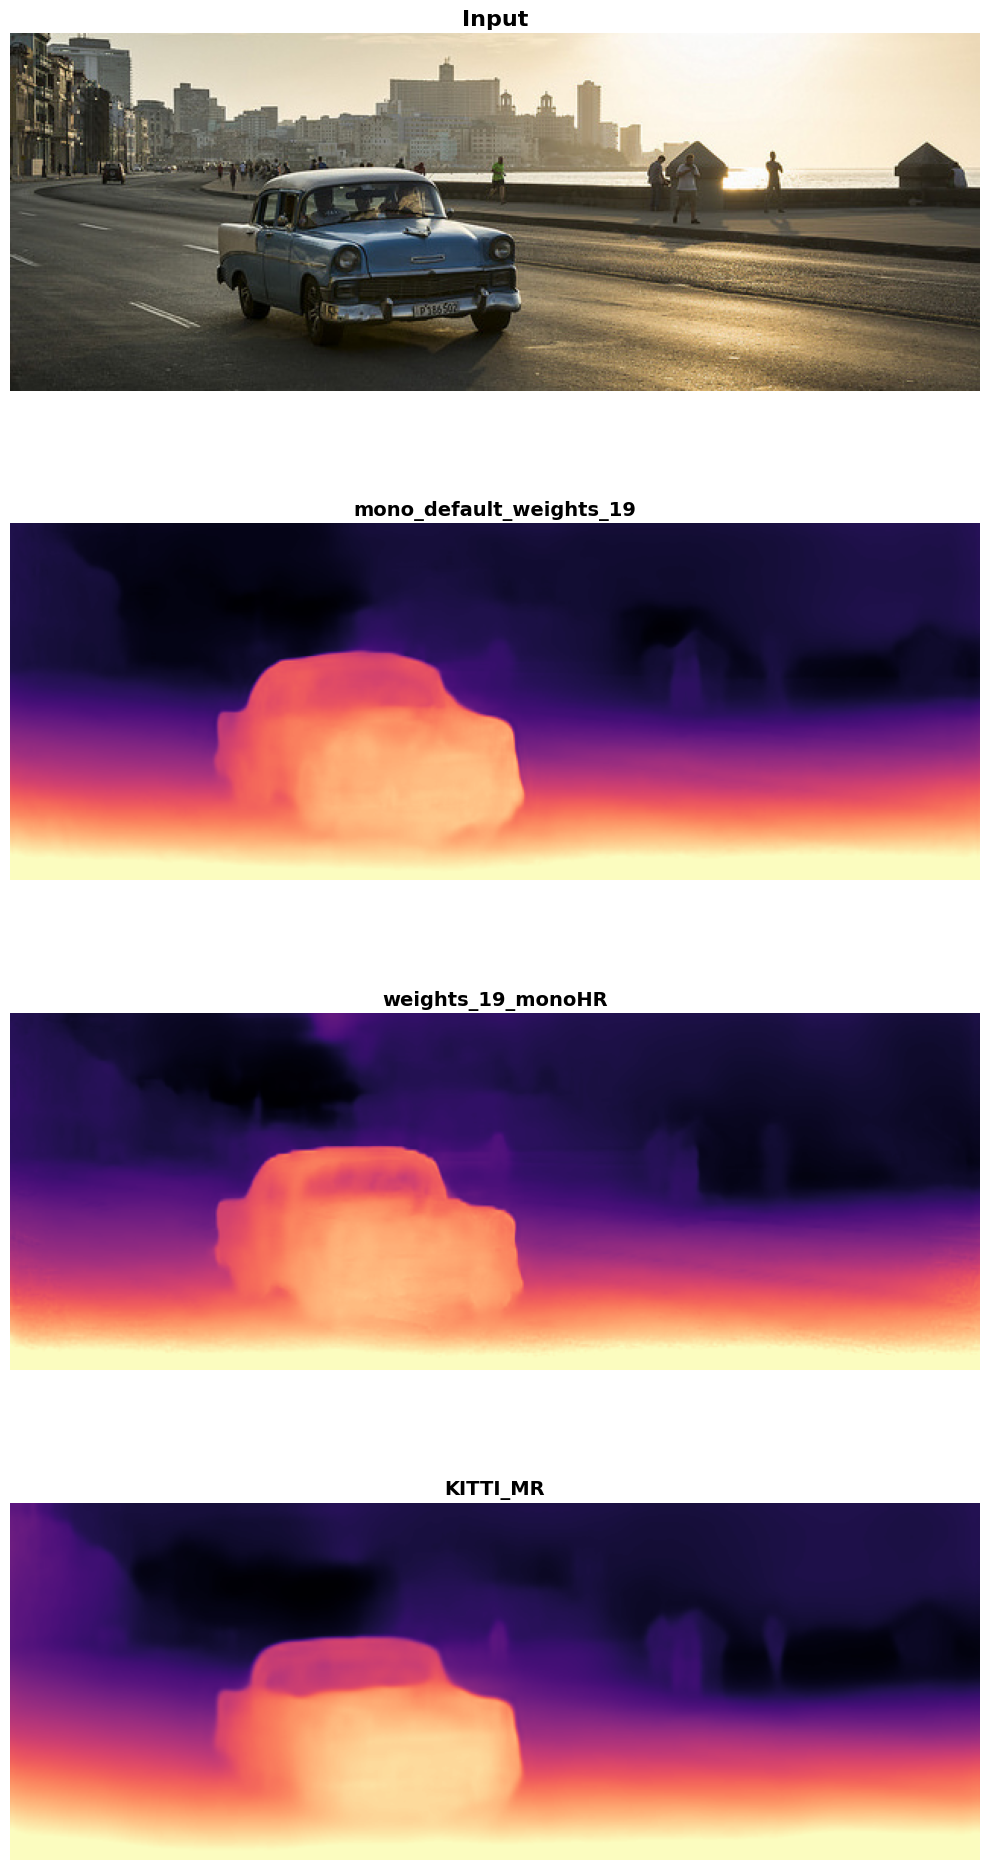

In [32]:
# Plot input and all predictions vertically
num_models = len(models)
plt.figure(figsize=(10, 5 * (num_models + 1)))

# Plot input image at the top
plt.subplot(num_models + 1, 1, 1)
plt.imshow(input_image)
plt.title("Input", fontsize=16, fontweight='bold')
plt.axis('off')

# Plot predictions for each model below
for idx, (model, disp) in enumerate(zip(models, predictions)):
    disp_resized = torch.nn.functional.interpolate(disp,
        (original_height, original_width), mode="bilinear", align_corners=False)
    
    disp_resized_np = disp_resized.squeeze().cpu().numpy()
    vmax = np.percentile(disp_resized_np, 95)
    
    plt.subplot(num_models + 1, 1, idx + 2)
    plt.imshow(disp_resized_np, cmap='magma', vmax=vmax)
    plt.title(f"{model['name']}", fontsize=14, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()